# Lab 9 – Morphological Image Processing
**Course:** ARTI404

**Student Name:** abdullah ibrahim amri   
**Student ID:** 2230001384

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Create Binary Image

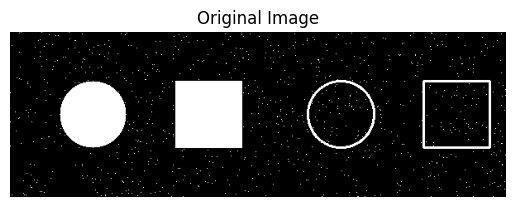

In [2]:
# Create image
image = np.zeros((200, 600), dtype=np.uint8)

cv2.circle(image, (100, 100), 40, 255, -1)
cv2.rectangle(image, (200, 60), (280, 140), 255, -1)
cv2.circle(image, (400, 100), 40, 255, 2)
cv2.rectangle(image, (500, 60), (580, 140), 255, 2)

# Add noise
np.random.seed(0)
for _ in range(1000):
    x, y = np.random.randint(0, 600), np.random.randint(0, 200)
    image[y, x] = 255

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

## Task 2: Square Kernel Operations

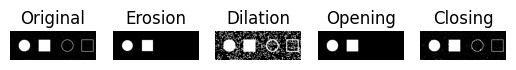

In [3]:
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(image, kernel)
dilation = cv2.dilate(image, kernel)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

titles = ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [image, erosion, dilation, opening, closing]

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

## Task 3: Circular Kernel Operations

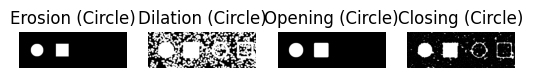

In [4]:
def circular_structuring_element(radius):
    size = 2 * radius + 1
    kernel = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(kernel, (radius, radius), radius, 1, -1)
    return kernel

radius = 5
circle_kernel = circular_structuring_element(radius)

erosion_c = cv2.erode(image, circle_kernel)
dilation_c = cv2.dilate(image, circle_kernel)
opening_c = cv2.morphologyEx(image, cv2.MORPH_OPEN, circle_kernel)
closing_c = cv2.morphologyEx(image, cv2.MORPH_CLOSE, circle_kernel)

titles = ['Erosion (Circle)', 'Dilation (Circle)', 'Opening (Circle)', 'Closing (Circle)']
images = [erosion_c, dilation_c, opening_c, closing_c]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

The square kernel produces sharper and more rigid changes in the image, which may distort curved shapes. The circular kernel produces smoother results and preserves the natural shape of objects, especially circular ones.